# Homework 07: Ensemble Methods – Gradient Boosting

#### Due: **Monday June 29th** @ 11:59 PM (with 2 hour & 1 minute grace period)

(I am moving the deadline because I posted it a day late.)

Over the past two weeks, we have expanded our machine learning toolkit by moving beyond linear regression to decision trees, which require careful selection of interacting hyperparameters. In Homework 6, you developed a systematic workflow for parameter tuning that balanced manual exploration with automated search methods (e.g., grid search) in order to optimize performance while gaining insight into model behavior.

This week, we take another step forward by studying **ensemble methods**, which combine multiple decision trees to produce stronger predictive models. Specifically, we will investigate **Gradient Boosting**, one of the most powerful and widely used non-deep learning methods in modern machine learning practice.

### What We Will Do in This Homework

To analyze and optimize our ensemble models, we will apply the two-phase strategy introduced in Homework 6. However, we will add **two new tools** to our tuning workflow:

* We will employ **randomized search instead of exhaustive grid search** to efficiently explore the hyperparameter space and identify promising regions without incurring the full combinatorial cost of evaluating every possible configuration.
* You will **store your best parameter values (and the resulting CV MAE) in a dictionary** to track improvements across experiments and maintain a clear record of how each parameter choice was made. This disciplined bookkeeping is essential for systematic model tuning.

Our two-phase strategy is thus (with new features in italics):

#### 1. First Phase

* Iteratively sweep through key parameters in **coarse ranges**, recording results in a dictionary
* Visualize training and cross-validation MAE
* Diagnose overfitting or underfitting
* Repeat the sweeps with progressively finer granularity
  (e.g., for `n_estimators`, you might begin with steps of 100, then refine to steps of 50, then 25, etc.)

#### 2. Second Phase

* Focus on the most promising or unstable parameter ranges identified in Phase 1
* Perform a randomized search within these narrower ranges using `RandomizedSearchCV`

We will follow this process for `GradientBoostingRegressor`, systematically tuning the most important parameters (see **Appendix 1** for a complete list):

`n_estimators`, `max_depth`, `max_features`, `min_samples_split`, `subsample`

### Why We Are Not Tuning `learning_rate`

We will **not** tune `learning_rate` in this assignment.

In practice, `learning_rate` and `n_estimators` are tightly coupled: reducing the learning rate typically requires increasing the number of boosting stages. However, to isolate and reinforce the workflow of structured hyperparameter tuning, we will hold `learning_rate` fixed at its default value.

Gradient boosting models can appear to improve continuously as more estimators are added (particularly when the learning rate is small). However, this can lead to subtle overfitting. Overfitting can be controlled in several ways, including:

* Early stopping
* Monitoring the variance of cross-validation scores
* Comparing with a held-out test set (as a final check only)

In this homework, we will control overfitting in a simplified way by fixing the learning rate and tuning the remaining structural parameters. The goal is to strengthen your understanding of systematic model selection.

### Cross-Validation Strategy

We will continue using `RepeatedKFold` cross-validation to reduce variance in our CV MAE estimates.

However, computational cost increases quickly with the number of repeats. Use a staged approach:

* **Explore:** `n_repeats = 1`
* **Confirm:** `n_repeats = 3`
* **Finalize:** `n_repeats = 5` (only on your final 1–2 candidate models)

Be strategic about computational budget. Large sweeps with many repeats can significantly increase runtime.

### Before Starting

* Review the ensemble methods lesson materials, especially the Gradient Boosting video and notebook. The code in this homework builds directly on those resources.
* Refer to **Appendix 2** for tuning strategy guidance.
* Refer to **Appendix 3** for a comparison of randomized search and exhaustive grid search.

### Grading

This homework consists of 9 graded problems, each worth 6 points, and you get 1 point free if you complete the homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import zipfile
import time

from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble        import GradientBoostingRegressor
from sklearn.metrics         import mean_absolute_error
from tqdm                    import tqdm

import matplotlib.ticker as mticker           # Optional: you can print out y axis labels as dollars. 

# globals

random_seed = 42

# utility code

# Optional:  Format y-axis labels as dollars with commas
def dollar_format(x, pos):
    return f'${x:,.0f}'

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

### Load the Ames Housing Dataset  

The code cell below will load the dataset for you.  This is the same dataset we used for the last two homeworks. 

> **Notice** that this code includes a useful optimization: **before downloading, it first
checks whether the files already exist.** This is an essential step when working with large datasets or when building deep learning models, where training can span hours or even days. By reusing previously downloaded files or saved models, you can avoid unnecessary work and significantly speed up your workflow.

For a detailed description of the dataset features, please refer to the **Appendix** in Homework 05. 

In [2]:
data_dir = "Ames_Dataset"                              # Directory where files will be stored

# Check if one of the files exists; if not, download and extract the zip file

if not os.path.exists( os.path.join(data_dir, "X_train.csv") ):
    print("Dataset files not found. Downloading...")
    zip_url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/ames_housing.zip"
    try:
        response = requests.get(zip_url)
        response.raise_for_status()  # Raise an error for bad status codes
        # Extract the zip file into the designated directory
        with zipfile.ZipFile(io.BytesIO(response.content)) as zipf:
            zipf.extractall(data_dir)
        print("Files downloaded and extracted successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("Dataset files already exist. Skipping download.")

# Load the datasets
X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
X_test  = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).squeeze("columns")    
y_test  = pd.read_csv(os.path.join(data_dir, "y_test.csv")).squeeze("columns")

print("Training and testing datasets loaded successfully.")


Dataset files already exist. Skipping download.
Training and testing datasets loaded successfully.


## Prelude: Wrapper Functions for Running Ensemble Models

The following cells are adapted from the Week 7 video notebook on `GradientBoostingRegressor`, but have been refactored to be more generally useful (perhaps in your final project):

- **`run_model`** replaces the original `run_gradient_boosting_regressor` and accepts a parameter dictionary that can be applied to any model. You do not need to call this explicitly in this homework. 
- **`sweep_parameter`** is updated to work seamlessly with `run_model`, letting you:
  - Specify which model you want to use;  
  - Pass a dictionary of model parameters; and  
  - Return a modified parameter dictionary reflecting the best value of the parameter you swept, along with the corresponding MAE.

**Note:** Please do not change these cells unless you consult with the LFs first. Any alterations may cause downstream issues with the assignment.

In [ ]:
# Run the model for testing and returning metrics.
# NOTE: You can NOT use this for running the model on the test set.

def run_model(model, 
              X_train, y_train, 
              n_repeats=5, 
              n_jobs=-1, 
              **model_params
             ):

    # Instantiate the model if a class is provided
    # One star * unpacks a list or tuple as positional arguments
    # Two stars ** unpack a dictionary as keyword arguments (ordder does not matter)
    if isinstance(model, type):
        model = model(**model_params) # it creates a model object from the class via dictionary unpacking
    else:                                    
        model.set_params(**model_params)    # Update this existing model with these parameter values.

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model, 
        X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_seed), 
        n_jobs=n_jobs
    )
    
    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)
    
    return mean_cv_mae, std_cv_mae, train_mae


In [ ]:
def sweep_parameter(model,
                    Parameters, # dictionary of model parameters
                    param, # the one parameter to sweep
                    parameter_list, # values of that parameter to test
                    X_train          = X_train,              # Defined above
                    y_train          = y_train,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = False,
                    n_iter_no_change = None, #optional early stopping
                    delta            = 0.001, # minimal imrpovement needed
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):
    

    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  # Just in case
        
        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)
        
        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        if show_mae:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters



## Problem 1: Iterative Parameter Sweeping and Visualization with `sweep_parameter(...)`

In this problem, you’ll tune five key hyperparameters of `GradientBoostingRegressor` by manually sweeping their values and visualizing the results using **Mean Absolute Error (MAE)** as your evaluation metric.

> **Important:** `GradientBoostingRegressor` runs on the CPU (not the GPU), even in Colab. Runtime depends heavily on:
>
> * Number of parameter values per sweep
> * Number of cross-validation repeats
> * `n_jobs` (parallel workers)

Be strategic about computational cost.

### Recommended Workflow

**Phase A — Exploration (Fast Mode)**

* Use `n_repeats = 1` or `2`
* Limit each parameter sweep to **≤ 20 values**
* Use coarse step sizes
* Goal: identify promising regions quickly

**Phase B — Refinement (Standard Mode)**

* Use `n_repeats = 3`
* Narrow ranges around best values
* Use smaller step sizes
* Limit sweeps to **≤ 15 values**

**Phase C — Final Confirmation (Full Mode)**

* Use `n_repeats = 5`
* Only evaluate the final narrow ranges
* Do not re-run large coarse sweeps at full repeats

> If a single sweep is taking more than ~5–10 minutes, reduce:
>
> * number of parameter values
> * `n_repeats`
> * or set `n_jobs=2` or `4` instead of `-1`



### Goal

**Your goal is not necessarily to find the single lowest CV MAE observed, but rather a configuration that achieves consistently strong performance, appears stable across cross-validation runs, and is likely to generalize well.**

That being said, your objective is to apply a **coarse-to-fine tuning strategy**: begin with broad parameter ranges and coarse steps, then narrow the range and increase granularity as you approach a good model.

For example, when sweeping `n_estimators`, you might proceed as follows:

**Exploration:**

```python
range(200, 1201, 200)  # 6 values
```

**Refinement:**

```python
range(800, 1201, 50)   # 8 values
```

**Final confirmation:**

```python
range(900, 1001, 10)   # 11 values
```

Avoid sweeping hundreds of values — this will dramatically increase runtime.


### Step-by-Step Sweeping Procedure

#### Tip on Repeats

* Use **1–2 repeats** for early sweeps
* Increase to **3 repeats** for refinement
* Use **5 repeats only for final confirmation**

Do not run large coarse sweeps with 5 repeats.


#### 1. Sweep `n_estimators` (*integer values*)

* Start with a **coarse range** (e.g., 200–1200 step 200)
* Use `n_repeats = 1` or `2`
* Plot results and update `Parameters_GB`
* Narrow the range around the best region

#### 2. Sweep `max_depth` (*integer values*)

* Try small integers (e.g., 2–6 initially)
* Use step size of 1 or 2
* Avoid sweeping large depth ranges unnecessarily



#### 3. Sweep `max_features` (*integer values*)

* Check `X_train.shape` for the feature count
* Use a reasonable subset (e.g., increments of 5 or 10)
* Avoid sweeping from 1 to full feature count unless justified



#### 4. Sweep `min_samples_split`

* Try small integer ranges (e.g., 2–15 step 3–5)
* Avoid large ranges



#### 5. Sweep `subsample` (*fractional values*):

   * Test fractions such as 0.4, 0.6, 0.8, and 1.0
   * Begin with a step size of 0.2
   * This controls the fraction of training samples used to train each tree

**Note:** After each sweep update `Parameters_GB`.

### Repeat with Finer Granularity

After the first pass:

* Narrow each parameter range around the best region
* Use smaller step sizes
* Reduce the number of candidate values
* Increase `n_repeats` gradually

You do **not** need to resweep every parameter each time.

Eventually aim for:

* `n_estimators`: step size of 10 (or 5 if runtime allows)
* Others: step size of 1 or 2

But only in narrow ranges.



### Ensure Robustness

Your final configuration must:

* Use **at least 5 repeats**
* Be based on narrow, well-justified ranges
* Reflect clear CV MAE improvement

This final configuration will form the foundation for Problem 2.



### Final Reporting

After completing 2–3 rounds of parameter sweeping:

* Report final tuned values stored in `Parameters_GB`
* Display final **CV MAE** clearly (in dollars)
* Respond to the graded question


In [5]:
Default_Parameters_GB = {
    'n_estimators'            : 100,             # The number of boosting stages to be run. More estimators can improve performance but increase training time.
    'max_depth'               : 3,               # Maximum depth of individual trees. Controls model complexity.
    'max_features'            : None,            # Number of features to consider when looking for best split. Can help reduce overfitting.
    'min_samples_split'       : 2,               # Defines the minimum number of samples required to split an internal node.
    'subsample'               : 1.0,             # Fraction of the training data used to train each tree; values less than 
                                                 #    1.0 introduce randomness and can reduce overfitting.
    'random_state'            : random_seed,     # Controls randomness of boosting. Useful for reproducibility.
    'MAE_found'               : float('inf')     # NOT a model parameter, but will record the MAE found for the current parameter choices
}


In [6]:
# Make a copy of the default dictionary

Params_GB = Default_Parameters_GB.copy()


In [9]:
list(range(200, 1201, 200))

[200, 400, 600, 800, 1000, 1200]

Sweeping n_estimators: 100%|██████████| 6/6 [03:45<00:00, 37.57s/it]


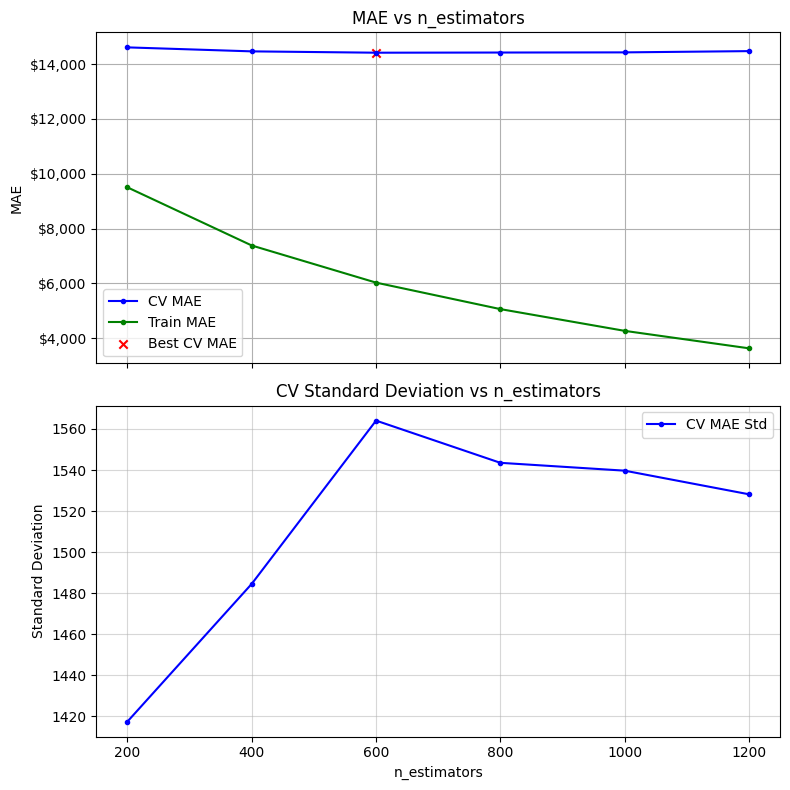

Execution Time: 00:03:46


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': None,
 'min_samples_split': 2,
 'subsample': 1.0,
 'random_state': 42,
 'MAE_found': np.float64(14416.831161963306)}

In [7]:
# Your code here, add as many cells as you need
# Start with n_estimators

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param='n_estimators',
    parameter_list=range(200, 1201, 200),
    X_train=X_train,
    y_train=y_train,
    n_repeats=1,
    n_jobs=-1,
    show_std=True
)

Params_GB

Sweeping max_depth: 100%|██████████| 6/6 [05:02<00:00, 50.45s/it]


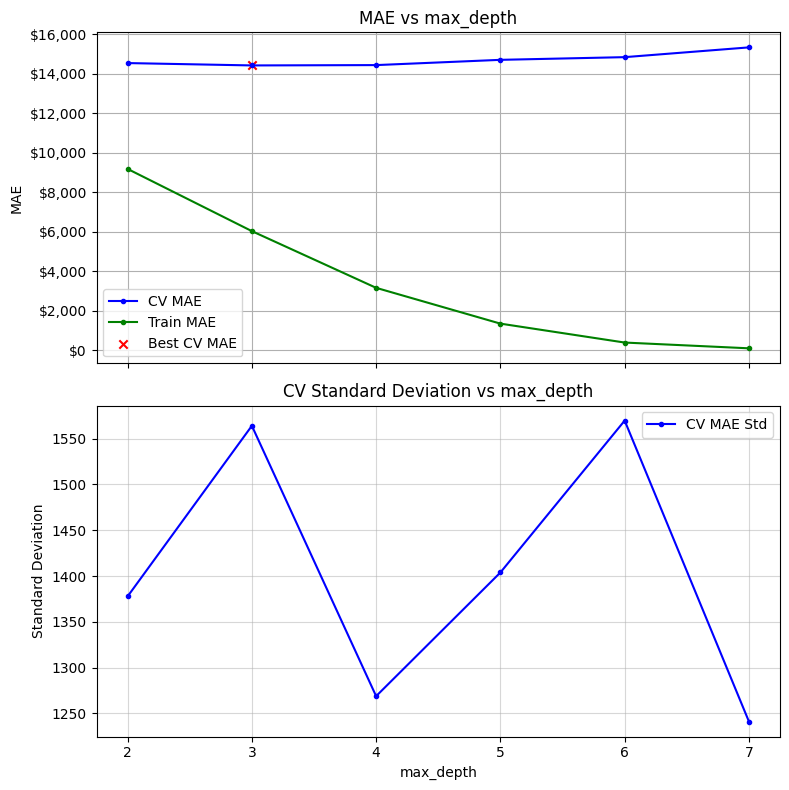

Execution Time: 00:05:03


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': None,
 'min_samples_split': 2,
 'subsample': 1.0,
 'random_state': 42,
 'MAE_found': np.float64(14416.831161963306)}

In [10]:
# max_depth

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param='max_depth',
    parameter_list=range(2, 8),
    X_train=X_train,
    y_train=y_train,
    n_repeats=1,
    n_jobs=-1,
    show_std=True
)

Params_GB

In [11]:
# ,ax_features: how many features the model can consider at each split

X_train.shape

(2344, 73)

Sweeping max_features: 100%|██████████| 7/7 [01:46<00:00, 15.24s/it]


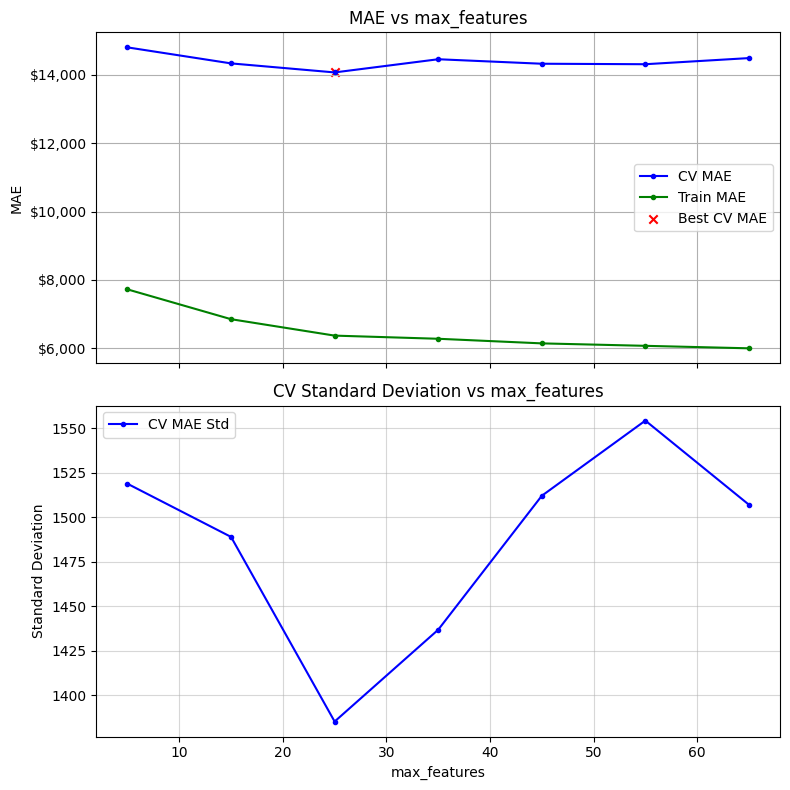

Execution Time: 00:01:47


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': 25,
 'min_samples_split': 2,
 'subsample': 1.0,
 'random_state': 42,
 'MAE_found': np.float64(14074.556713796908)}

In [14]:
Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param='max_features',
    parameter_list=range(5, X_train.shape[1] + 1, 10),
    X_train=X_train,
    y_train=y_train,
    n_repeats=1,
    n_jobs=-1,
    show_std=True
)

Params_GB

In [18]:
list(range(2, 27, 4))

[2, 6, 10, 14, 18, 22, 26]

Sweeping min_samples_split: 100%|██████████| 7/7 [01:30<00:00, 12.98s/it]


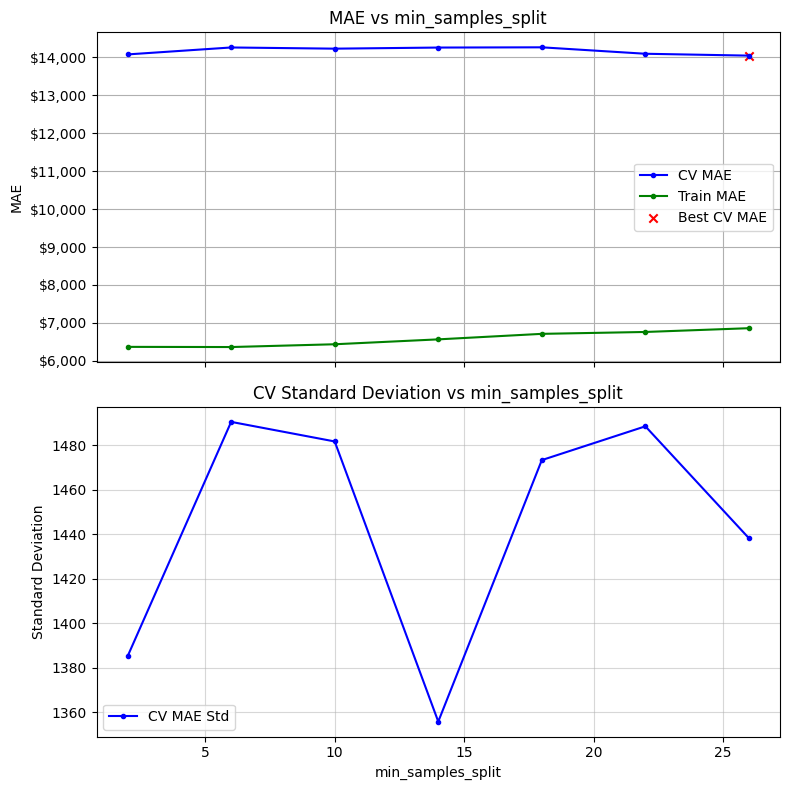

Execution Time: 00:01:31


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': 25,
 'min_samples_split': 26,
 'subsample': 1.0,
 'random_state': 42,
 'MAE_found': np.float64(14042.873824847193)}

In [19]:
# min_samples_split

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param='min_samples_split',
    parameter_list=range(2, 27, 4),
    X_train=X_train,
    y_train=y_train,
    n_repeats=1,
    n_jobs=-1,
    show_std=True
)

Params_GB

In [13]:
np.linspace(0.5, 1.0, 6)

array([0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

Sweeping subsample: 100%|██████████| 6/6 [01:32<00:00, 15.42s/it]


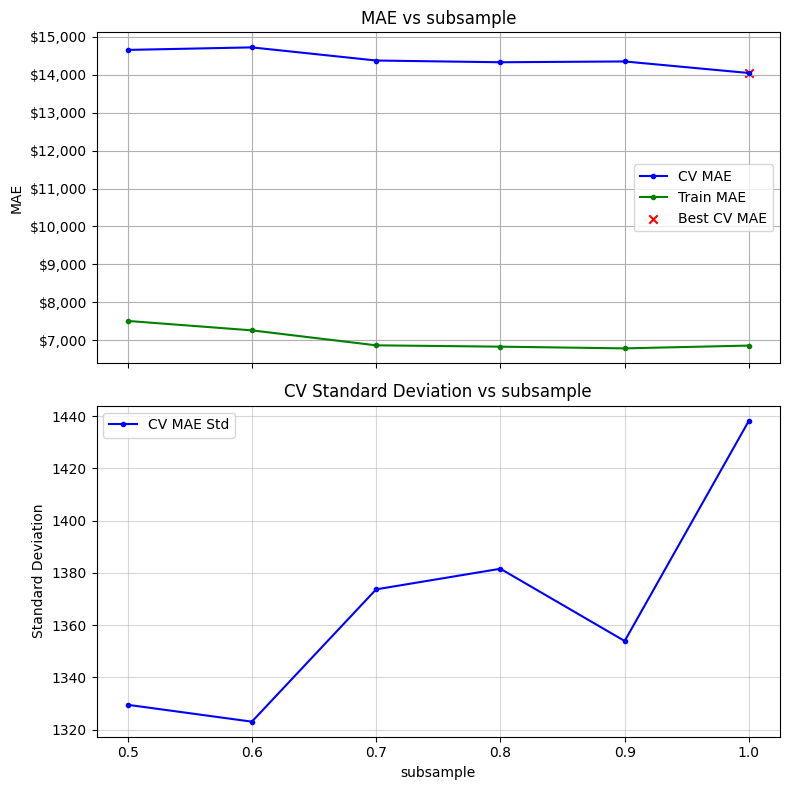

Execution Time: 00:01:32


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': 25,
 'min_samples_split': 26,
 'subsample': np.float64(1.0),
 'random_state': 42,
 'MAE_found': np.float64(14042.873824847193)}

In [20]:
# subsample (what fraction of training rows each tree sees)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param='subsample',
    parameter_list=np.linspace(0.5, 1.0, 6),
    X_train=X_train,
    y_train=y_train,
    n_repeats=1,
    n_jobs=-1,
    show_std=True
)

Params_GB

Sweeping n_estimators: 100%|██████████| 9/9 [03:59<00:00, 26.58s/it]


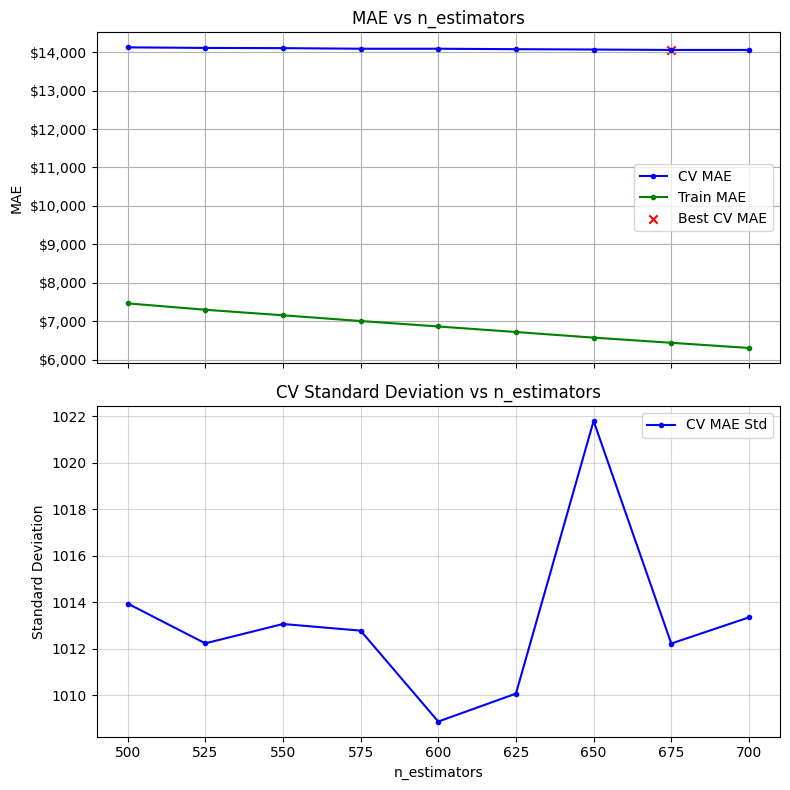

Execution Time: 00:04:00


Sweeping max_depth: 100%|██████████| 4/4 [02:06<00:00, 31.54s/it]


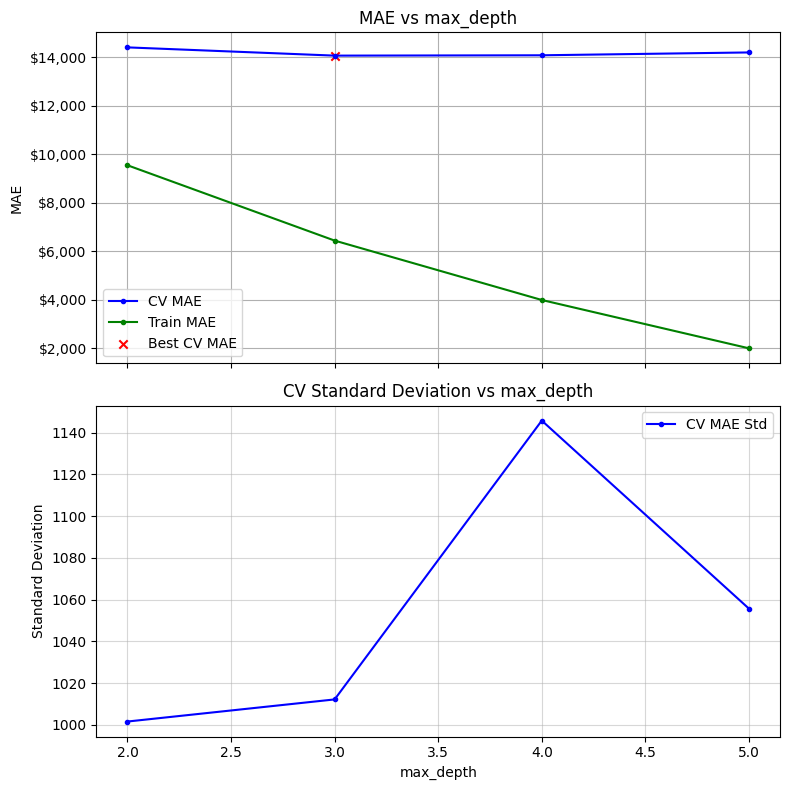

Execution Time: 00:02:06


Sweeping max_features: 100%|██████████| 11/11 [04:27<00:00, 24.36s/it]


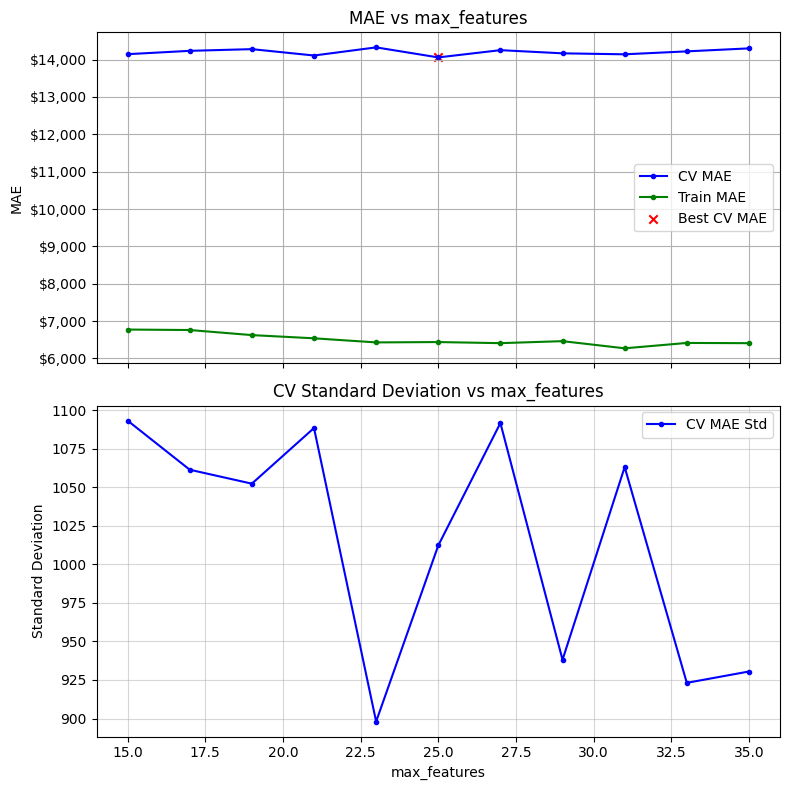

Execution Time: 00:04:29


Sweeping min_samples_split: 100%|██████████| 11/11 [04:21<00:00, 23.76s/it]


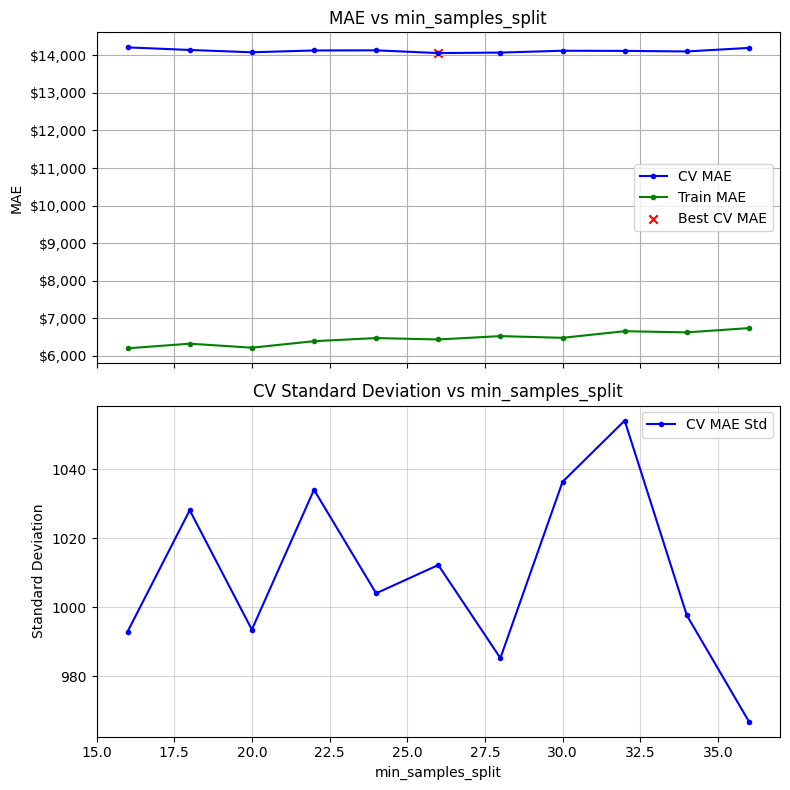

Execution Time: 00:04:21


Sweeping subsample: 100%|██████████| 7/7 [02:55<00:00, 25.04s/it]


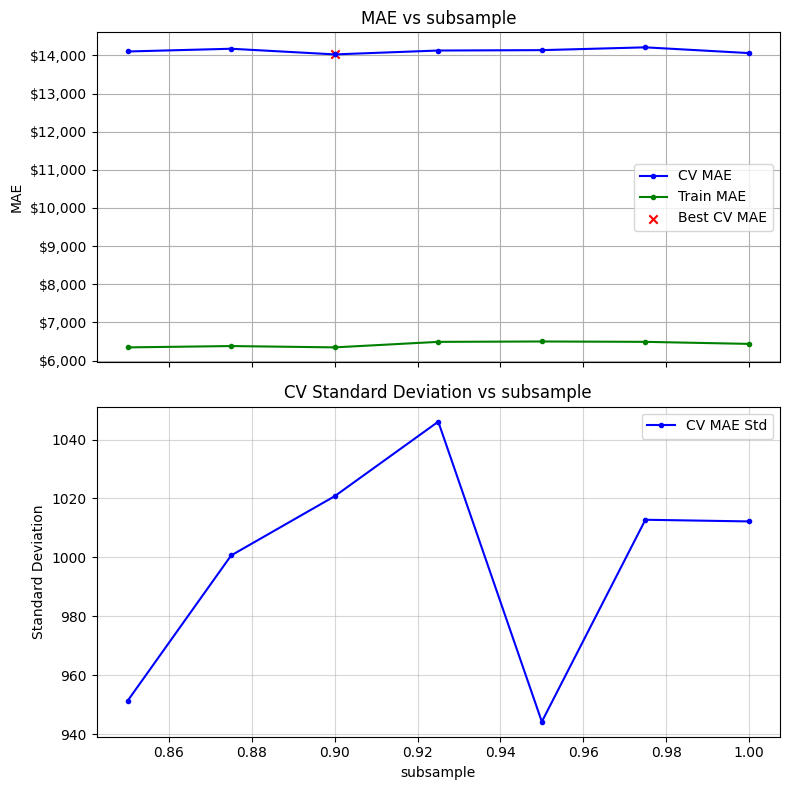

Execution Time: 00:02:55


{'n_estimators': 675,
 'max_depth': 3,
 'max_features': 25,
 'min_samples_split': 26,
 'subsample': np.float64(0.9),
 'random_state': 42,
 'MAE_found': np.float64(14025.406432062533)}

In [21]:
# Store Phase 1 result as baseline
phase1_mae = Params_GB["MAE_found"]

# Phase 2: narrower search around the Phase 1 best values
Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="n_estimators",
    parameter_list=range(500, 701, 25),
    X_train=X_train,
    y_train=y_train,
    n_repeats=3,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="max_depth",
    parameter_list=range(2, 6),
    X_train=X_train,
    y_train=y_train,
    n_repeats=3,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="max_features",
    parameter_list=range(15, min(36, X_train.shape[1] + 1), 2),
    X_train=X_train,
    y_train=y_train,
    n_repeats=3,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="min_samples_split",
    parameter_list=range(16, 37, 2),
    X_train=X_train,
    y_train=y_train,
    n_repeats=3,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="subsample",
    parameter_list=np.arange(0.85, 1.01, 0.025),
    X_train=X_train,
    y_train=y_train,
    n_repeats=3,
    n_jobs=-1,
    show_std=True
)

Params_GB

In [22]:
phase2_mae = Params_GB["MAE_found"]

Sweeping n_estimators: 100%|██████████| 11/11 [06:02<00:00, 32.94s/it]


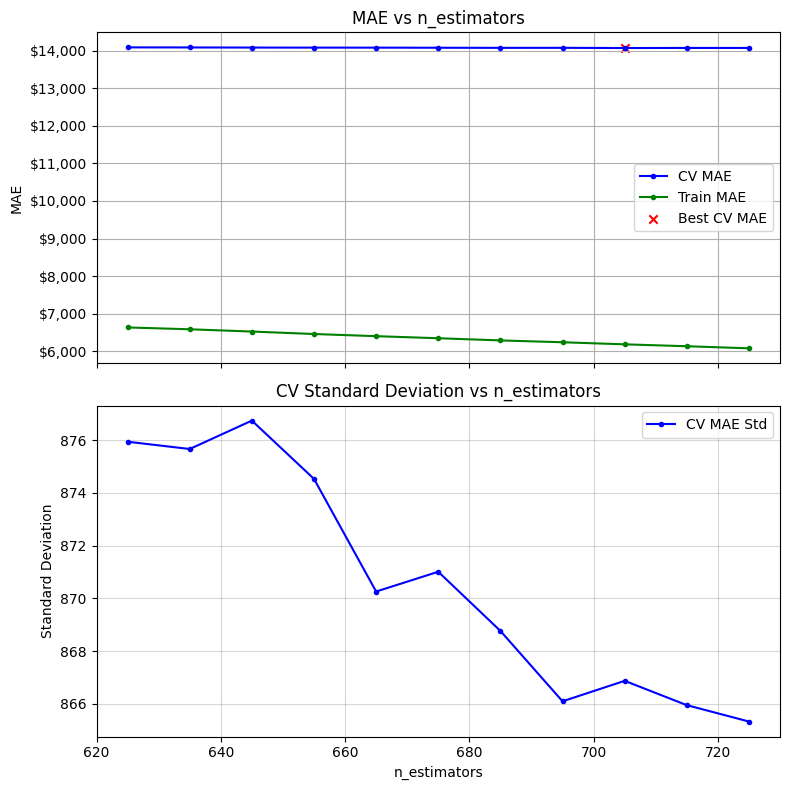

Execution Time: 00:06:02


Sweeping max_depth: 100%|██████████| 3/3 [01:25<00:00, 28.64s/it]


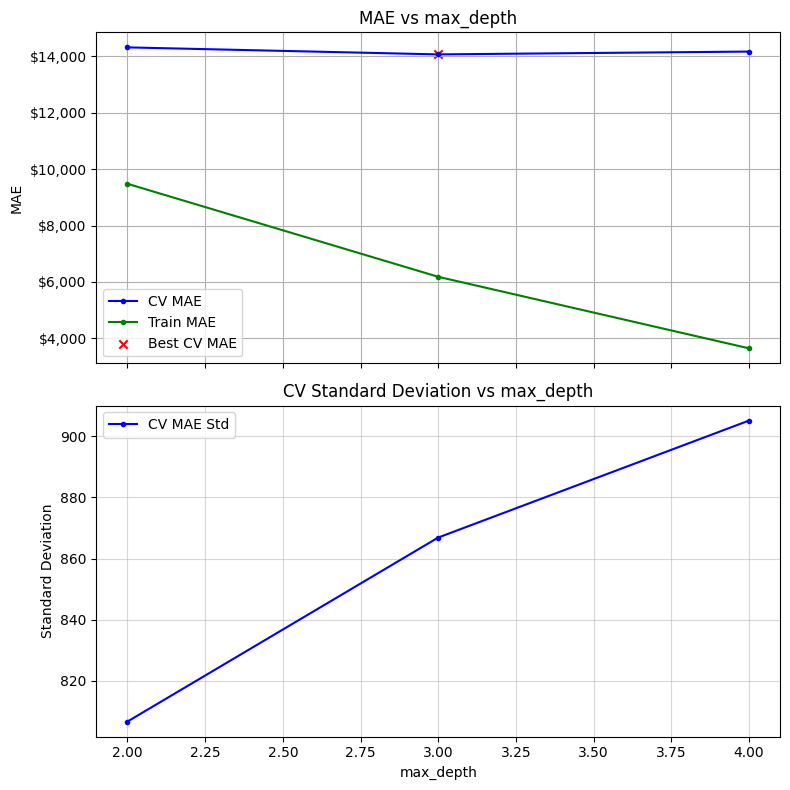

Execution Time: 00:01:26


Sweeping max_features: 100%|██████████| 7/7 [04:39<00:00, 39.91s/it]


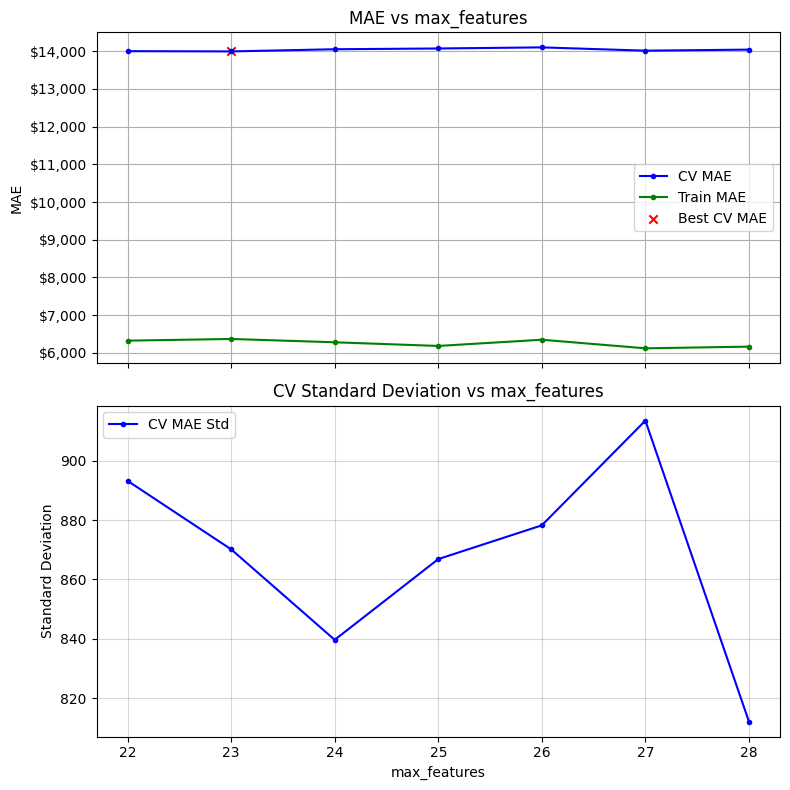

Execution Time: 00:04:39


Sweeping min_samples_split: 100%|██████████| 9/9 [06:01<00:00, 40.21s/it]


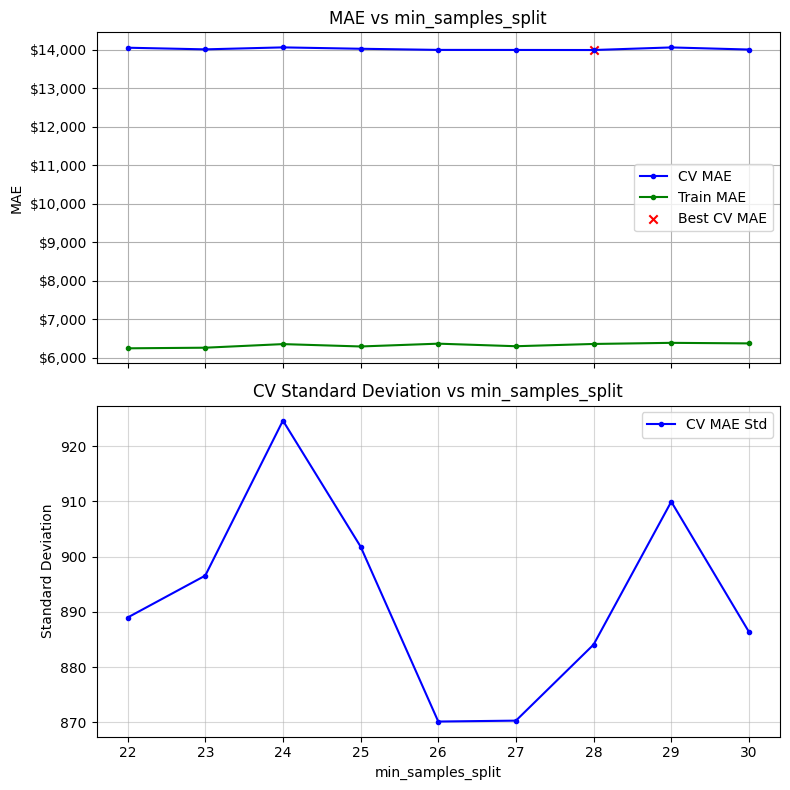

Execution Time: 00:06:02


Sweeping subsample: 100%|██████████| 11/11 [06:44<00:00, 36.77s/it]


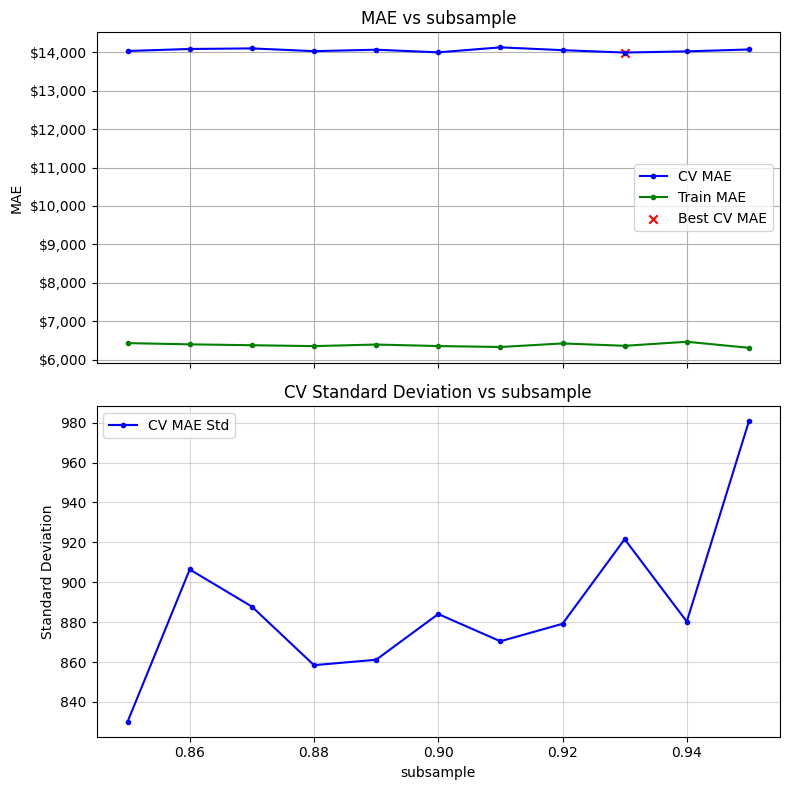

Execution Time: 00:06:45


{'n_estimators': 705,
 'max_depth': 3,
 'max_features': 23,
 'min_samples_split': 28,
 'subsample': np.float64(0.93),
 'random_state': 42,
 'MAE_found': np.float64(13986.923608645971)}

In [26]:
# Phase 3: final robust sweep with narrow ranges and at least 5 repeats

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="n_estimators",
    parameter_list=range(625, 726, 10),
    X_train=X_train,
    y_train=y_train,
    n_repeats=5,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="max_depth",
    parameter_list=range(2, 5),
    X_train=X_train,
    y_train=y_train,
    n_repeats=5,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="max_features",
    parameter_list=range(22, 29, 1),
    X_train=X_train,
    y_train=y_train,
    n_repeats=5,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="min_samples_split",
    parameter_list=range(22, 31, 1),
    X_train=X_train,
    y_train=y_train,
    n_repeats=5,
    n_jobs=-1,
    show_std=True
)

Params_GB = sweep_parameter(
    model=GradientBoostingRegressor,
    Parameters=Params_GB,
    param="subsample",
    parameter_list=np.arange(0.85, 0.96, 0.01),
    X_train=X_train,
    y_train=y_train,
    n_repeats=5,
    n_jobs=-1,
    show_std=True
)

Params_GB

In [27]:
phase3_mae = Params_GB["MAE_found"]

I can summarize the above process:
1. Default model recipe;
2. better recipe after n_estimators
3. better recipe after max_depth
4. better recipe after min_samples_split
5. better recipe after subsample
6. final Problem 1 recipe

What is a recipy? Of course our patrameter dict. We are cooking the best possible model :)

Important note: The above code (sweeping) is equential in the oposite to the gridsearch. We shouldn't forget that parmeters interact with each other. For example, the best n_estimators may change after we change max_depth. That's why these 3 rounds define very practical approach, cuz it is like letting the parameters adjust to each other gradually.

### Problem 1 Graded Answer

Set `a1` to the CV MAE score of your best model. 

In [28]:
 # Your answer here

a1 = phase3_mae                     # replace 0 with your answer

In [29]:
# DO NOT change this cell in any way

print(f'a1 = ${a1:,.2f}')

a1 = $13,986.92


## Problem 2: Use `RandomizedSearchCV` to Explore Alternatives

In this problem, you will use **randomized search** to explore the hyperparameter space more broadly than in Problem 1.

Rather than sweeping one parameter at a time, `RandomizedSearchCV` samples random combinations of parameters from specified distributions. This allows you to explore interactions between parameters more efficiently than manual sweeps.

Use the final parameter ranges you identified in Problem 1 — or slightly narrower ranges centered around your best values.


### Setup Requirements

* Define parameter distributions using `randint(lb, ub)` for **all** five parameters.

  * Remember that `randint(a, b)` samples integers from `a` to `b - 1`.
  * This gives you a granularity of 1 automatically.
* Use `RepeatedKFold` for cross-validation so that your scoring is consistent with Problem 1.
* Use `scoring='neg_mean_absolute_error'`.


### Runtime Strategy (Very Important)

Randomized search can become expensive quickly. Be strategic.

Start conservatively:

```python
n_iter = 30
n_repeats = 2
```

If runtime is comfortable (e.g., under ~15–20 minutes total), you may increase gradually:

* Try `n_iter = 60`
* Or increase to `n_repeats = 3`

Only increase these values if your notebook is running smoothly and not approaching time or memory limits.

> ⚠️ Do not immediately set `n_iter=100` with 5 repeats. That can result in thousands of model fits and long runtimes.

Your goal is not to exhaust the search space — it is to intelligently explore it.



### What to Report

After fitting `RandomizedSearchCV`:

* Print the best parameter combination (`best_params_`)
* Report the corresponding **CV MAE**
* Set `a2` equal to the best CV MAE found



### Interpretation

It is entirely possible that randomized search does **not** outperform your manually tuned model from Problem 1.
Randomized search is most valuable when:

* The search space is large
* Parameter interactions matter
* Manual sweeping becomes inefficient

Its purpose here is to broaden exploration and compare strategies — not to guarantee improvement.



In [30]:
# Your code here -- Add as many code cells as necessary

n_iterations = 30            # How many samples to take from the distributions shown here (rest are defaults):  

param_distributions = {
    "n_estimators"      : randint(600, 751),
    "max_depth"         : randint(2, 5),
    "max_features"      : randint(20, min(31, X_train.shape[1] + 1)),
    "min_samples_split" : randint(20, 33),
    "subsample"         : uniform(0.85, 0.15)
}

# Initialize the GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_distributions,
    n_iter=n_iterations,
    scoring="neg_mean_absolute_error",
    cv=RepeatedKFold(n_splits=5, n_repeats=2, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# Fit the randomized search on the training data
random_search.fit(X_train, y_train)

# Convert best CV score from negative MAE to positive MAE
best_cv_mae = -random_search.best_score_

# Convert the CV results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Add readable positive MAE columns
results_df["mean_cv_mae"]    = -results_df["mean_test_score"]  # average validation score across those 5 CV folds
results_df["std_cv_mae"]     =  results_df["std_test_score"]
results_df["mean_train_mae"] = -results_df["mean_train_score"]

# Sort by mean_test_score.
top10 = (
    results_df
    .sort_values(by="mean_cv_mae", ascending=True)
    .head(10)
)

# Display the 10 best models
print("Top 10 models:")
print(
    top10[
        [
            "params",
            "mean_cv_mae",
            "std_cv_mae",
            "mean_train_mae"
        ]
    ].to_string(index=False)
)

# Output the best parameters and CV MAE
print("\nBest parameters:")
print(random_search.best_params_)

print(f"\nBest CV MAE: ${best_cv_mae:,.2f}")

Fitting 10 folds for each of 30 candidates, totalling 300 fits
Top 10 models:
                                                                                                             params  mean_cv_mae  std_cv_mae  mean_train_mae
{'max_depth': 3, 'max_features': 23, 'min_samples_split': 31, 'n_estimators': 710, 'subsample': 0.9524895278238187} 14148.027705 1009.770793     5635.155533
{'max_depth': 4, 'max_features': 23, 'min_samples_split': 32, 'n_estimators': 614, 'subsample': 0.9597990912717107} 14163.735830 1113.822269     3693.730630
{'max_depth': 3, 'max_features': 24, 'min_samples_split': 26, 'n_estimators': 742, 'subsample': 0.9633326707814572} 14212.017807 1078.441449     5414.850099
{'max_depth': 4, 'max_features': 29, 'min_samples_split': 31, 'n_estimators': 614, 'subsample': 0.9184104976325553} 14217.223701  948.174918     3453.596498
{'max_depth': 3, 'max_features': 25, 'min_samples_split': 21, 'n_estimators': 620, 'subsample': 0.9426222264441575} 14228.663812 1137.750

In [37]:
print(
    top10[
        [
            "params",
            "mean_cv_mae",
            "std_cv_mae",
            "mean_train_mae"
        ]
    ].to_string(index=False)
)

                                                                                                             params  mean_cv_mae  std_cv_mae  mean_train_mae
{'max_depth': 3, 'max_features': 23, 'min_samples_split': 31, 'n_estimators': 710, 'subsample': 0.9524895278238187} 14148.027705 1009.770793     5635.155533
{'max_depth': 4, 'max_features': 23, 'min_samples_split': 32, 'n_estimators': 614, 'subsample': 0.9597990912717107} 14163.735830 1113.822269     3693.730630
{'max_depth': 3, 'max_features': 24, 'min_samples_split': 26, 'n_estimators': 742, 'subsample': 0.9633326707814572} 14212.017807 1078.441449     5414.850099
{'max_depth': 4, 'max_features': 29, 'min_samples_split': 31, 'n_estimators': 614, 'subsample': 0.9184104976325553} 14217.223701  948.174918     3453.596498
{'max_depth': 3, 'max_features': 25, 'min_samples_split': 21, 'n_estimators': 620, 'subsample': 0.9426222264441575} 14228.663812 1137.750820     5938.570401
{'max_depth': 4, 'max_features': 26, 'min_samples_split': 

In [40]:
# Your code here -- Add as many code cells as necessary
# Train candidate models using GradientBoostingRegressor’s default squared-error loss.
# Select the best candidate using cross-validated MAE.

n_iterations = 60            # How many samples to take from the distributions shown here (rest are defaults):  

param_distributions = {
    "n_estimators"      : randint(600, 751),
    "max_depth"         : randint(2, 5),
    "max_features"      : randint(20, min(31, X_train.shape[1] + 1)),
    "min_samples_split" : randint(20, 33),
    "subsample"         : uniform(0.85, 0.15) # Although the prompt mentions `randint`, I used `uniform` for `subsample` because `subsample` is a continuous fractional parameter between 0 and 1. The remaining integer-valued parameters use `randint`.
}

# Initialize the GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_distributions,
    n_iter=n_iterations,
    scoring="neg_mean_absolute_error",
    cv=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# Fit the randomized search on the training data
random_search.fit(X_train, y_train)

# Convert best CV score from negative MAE to positive MAE
best_cv_mae = -random_search.best_score_

# Convert the CV results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Add readable positive MAE columns
results_df["mean_cv_mae"]    = -results_df["mean_test_score"]  # average validation score across those 10 CV folds
results_df["std_cv_mae"]     =  results_df["std_test_score"]
results_df["mean_train_mae"] = -results_df["mean_train_score"]

# Sort by mean_test_score.
top10 = (
    results_df
    .sort_values(by="mean_cv_mae", ascending=True)
    .head(10)
)

# Display the 10 best models
print("Top 10 models:")
print(
    top10[
        [
            "params",
            "mean_cv_mae",
            "std_cv_mae",
            "mean_train_mae"
        ]
    ].to_string(index=False)
)

# Output the best parameters and CV MAE
print("\nBest parameters:")
print(random_search.best_params_)

print(f"\nBest CV MAE: ${best_cv_mae:,.2f}")

Fitting 15 folds for each of 60 candidates, totalling 900 fits
Top 10 models:
                                                                                                             params  mean_cv_mae  std_cv_mae  mean_train_mae
{'max_depth': 3, 'max_features': 24, 'min_samples_split': 31, 'n_estimators': 667, 'subsample': 0.8621279989499072} 14008.877800  894.668299     5879.588953
{'max_depth': 4, 'max_features': 28, 'min_samples_split': 22, 'n_estimators': 692, 'subsample': 0.8925881462106199} 14020.248242  933.995433     2786.201903
{'max_depth': 3, 'max_features': 28, 'min_samples_split': 24, 'n_estimators': 733, 'subsample': 0.9184801855724365} 14057.976427  923.221133     5303.554493
{'max_depth': 4, 'max_features': 26, 'min_samples_split': 20, 'n_estimators': 651, 'subsample': 0.9344913357964575} 14068.912753  954.656467     3026.965101
  {'max_depth': 4, 'max_features': 21, 'min_samples_split': 22, 'n_estimators': 712, 'subsample': 0.87221303949301} 14072.678977  909.251

In [67]:
random_search.best_estimator_

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",667
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",np.float64(0.8621279989499072)
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",31
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the n

In [66]:
# Let's assess the diff between training and CV_test data.
# RandomizedSearchCV automatically refits the best model on the entire training sample after cross-validation
# Stage 1: Cross-validation search
# Stage 2: Refit best model on full X_train, that is Best hyperparameters found -> Train final model on entire X_train -> Store it as random_search.best_estimator_

best_model_p2 = random_search.best_estimator_

train_preds_p2 = best_model_p2.predict(X_train)

train_mae_p2 = mean_absolute_error(y_train, train_preds_p2)

print(f"Train MAE of best refitted model: ${train_mae_p2:,.2f}")

Train MAE of best refitted model: $6,618.77


### Problem 2 Graded Answer

Set `a2` to the best CV MAE score found using randomized search.

In [41]:
 # Your answer here

a2 = best_cv_mae                     # replace 0 with your answer  

In [42]:
# DO NOT change this cell in any way

print(f'a2 = ${a2:,.2f}')

a2 = $14,008.88


## Problem 3: Evaluate and Select Your Final Model

At this point, you may have **two candidate models**:

1. The model obtained from **Problem 1** (manual parameter sweeps)
2. The model obtained from **Problem 2** (`RandomizedSearchCV`)

Your task is to select **one final model** and evaluate it on the **held-out test set**.


### Step 1: Choose the Best Model (Using CV Only)

Base your decision primarily on:

* **Mean CV MAE**
* Stability of CV results
* Gap between training MAE and CV MAE (sign of overfitting)

Guidelines:

* Prefer the model with the **lower CV MAE**
* If CV MAE values are very close, prefer the model with:

  * Smaller training–CV gap
  * More stable behavior across parameter ranges
* If the two models are indistinguishable within reasonable CV variability, either choice is acceptable.

> Do **not** use the test set to decide between models.


### Step 2: Train the Final Model and Evaluate on the Test Set

Once you have selected your final configuration:

* Instantiate a new `GradientBoostingRegressor` with the chosen parameters
* Fit it on the **full training set**
* Generate predictions on the **test set**
* Compute the **test MAE**

This test MAE is your final out-of-sample performance estimate.

> **Important:** You can not use `run_model` here. That function is designed for cross-validation during tuning.
> As in Homework 06, you must explicitly fit the final model and evaluate it on `X_test` and `y_test`.


### What to Report

* `a3a`: Which model you selected

  * `1` = Problem 1 model
  * `2` = Problem 2 model
  * `3` = Essentially the same model
* `a3b`: The final **test MAE** (in dollars)


### Conceptual Reminder

Cross-validation is used for **model selection**.
The test set is used **once**, at the end, to estimate generalization performance.



In [44]:

results_df.sort_values(by="mean_cv_mae", ascending=True).head(1)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,param_subsample,params,...,split10_train_score,split11_train_score,split12_train_score,split13_train_score,split14_train_score,mean_train_score,std_train_score,mean_cv_mae,std_cv_mae,mean_train_mae
40,10.124835,2.242444,0.032134,0.018231,3,24,31,667,0.862128,"{'max_depth': 3, 'max_features': 24, 'min_samp...",...,-5929.437883,-5783.671027,-5951.146808,-5932.3458,-5789.048482,-5879.588953,94.360591,14008.8778,894.668299,5879.588953


In [46]:
# Your code here

param_distributions = {
    "n_estimators"      : 705,
    "max_depth"         : 3,
    "max_features"      : 23,
    "min_samples_split" : 28,
    "subsample"         : 0.93,
    "random_state": 42
}

# Initialize the GradientBoostingRegressor
gbr = GradientBoostingRegressor(**param_distributions)

gbr.fit(X_train,y_train)

y_test_pred = gbr.predict(X_test)

test_MAE = mean_absolute_error(y_test_pred,y_test)

print(f"Test MAE: {test_MAE:.4f}")

Test MAE: 14564.5730


I selected the Problem 1 model because it had the lowest mean CV MAE. However, the difference between Problem 1 and Problem 2 is very small relative to the CV standard deviation, so the two models are practically very similar

### Problem 3 Graded Answers

Set `a3a` to the number of the best model found:
- 1 = Problem 1 model
- 2 = Problem 2 model
- 3 = Essentially the same model

In [47]:
 # Your answer here

a3a = 1                    # replace 0 with one of 1, 2, or 3

In [48]:
# DO NOT change this cell in any way

print(f'a3a = {a3a}')

a3a = 1


Set `a3b` to the test MAE of your best model. 

In [61]:
 # Your answer here

a3b = test_MAE                     # replace 0 with your answer

In [62]:
# DO NOT change this cell in any way

print(f'a3b = ${a3b:,.2f}')

a3b = $14,564.57


## **Problem Four: Analytical Questions**

Select the single **best** answer to each of the following multiple choice questions on this week's material.

### Part A: Random Forests vs. Bagging

A Bagging model contains many trees, but most trees repeatedly split on the same strong predictor near the top of the tree.

Why might a Random Forest perform better?

1. It uses fewer trees.
2. It eliminates bootstrap sampling.
3. It forces trees to consider different subsets of features.
4. It guarantees zero overfitting.

In [51]:
# Your answer here. 

a4a = 3                    # Must be one of 1, 2, 3, 4

In [52]:
### Do not change this cell in any way

print(f'a4a = {a4a}')

a4a = 3


### Part B: Understanding Boosting

Which statement best describes how Boosting differs from Bagging?

1. Boosting builds trees independently and averages them.
2. Boosting trains each new tree to help correct previous errors.
3. Boosting eliminates the need for hyperparameter tuning.
4. Boosting always uses deeper trees than Bagging.

In [53]:
# Your answer here. 

a4b = 2                   # Must be one of 1, 2, 3, 4

In [54]:
# Do not change this cell in any way

print(f'a4b = {a4b}')

a4b = 2


### Part C: Learning Rate Tradeoff

Suppose you decrease the learning rate in a Gradient Boosting model.

Which adjustment is often necessary?

1. Use fewer trees.
2. Use more trees.
3. Remove cross-validation.
4. Increase the test-set size.

In [55]:
# Your answer here. 

a4c = 2                    # Must be one of 1, 2, 3, 4

In [56]:
# Do not change this cell in any way

print(f'a4c = {a4c}')

a4c = 2


### Part D: Overfitting in Boosting

A Gradient Boosting model achieves:

> Training MAE = \$4,000
>
> CV MAE = \$18,000

What is the most reasonable conclusion?

1. The model is likely overfitting.
2. The model is underfitting.
3. The model is unbiased.
4. The model has data leakage.

In [57]:
# Your answer here. 

a4d = 1                    # Must be one of 1, 2, 3, 4

In [58]:
# Do not change this cell in any way

print(f'a4d = {a4d}')

a4d = 1


### Part E: Diversity in an Ensemble

Suppose an ensemble contains three decision trees:

> Tree A and Tree B always make exactly the same predictions.    
> Tree C makes independent predictions.

The ensemble uses majority voting.

What is the most likely consequence?

1. Accuracy will always be higher than any individual tree.
2. The ensemble will behave exactly like a single tree represented by Trees A and B.
3. Overfitting will be eliminated because three trees are used.
4. The ensemble has become a Boosting model.

In [59]:
# Your answer here. 

a4e = 2                   # Must be one of 1, 2, 3, 4

In [60]:
# Do not change this cell in any way

print(f'a4e = {a4e}')

a4e = 2


## Appendix 1: Which `GradientBoostingRegressor` parameters are most important?

We will focus on parameters 2 -- 6 in this list. 

---


1. **learning_rate** (default: **0.1**)  
   *Controls the contribution of each individual tree. A lower learning rate generally requires more trees but can lead to improved generalization.*

2. **n_estimators** (default: **100**)  
   *Specifies the number of boosting stages (i.e., the number of trees in the ensemble). More estimators can improve performance but also increase the risk of overfitting if not tuned properly.*

3. **max_depth** (default: **3**)  
   *Limits the depth of the individual regression trees. Restricting the depth helps control overfitting and reduces the complexity of each base learner.*

4. **max_features** (default: **None**)  
   *Controls the number of features to consider when looking for the best split. Adjusting this can influence the bias-variance trade-off of the model.*

5. **subsample** (default: **1.0**)  
   *Determines the fraction of samples used for fitting each individual tree. Values less than 1.0 introduce randomness into the boosting process, which can help reduce overfitting.*

6. **min_samples_split** (default: **2**)  
   *Defines the minimum number of samples required to split an internal node. This parameter controls the growth of each tree and can prevent overly specific splits.*

7. **min_samples_leaf** (default: **1**)  
   *Specifies the minimum number of samples that must be present in a leaf node. This helps in ensuring that trees do not become too tailored to the training data.*

8. **max_leaf_nodes** (default: **None**)  
    *An optional parameter that sets a maximum number of leaf nodes for each tree. This can provide an additional way to control the complexity of the model.*

9. **loss** (default: **'squared_error'**)  
   *Determines the loss function to be optimized during training. Different loss functions can be used depending on the specific characteristics of the regression problem.*





## Appendix 2: Tuning and Selecting Complex Models

This appendix offers practical guidance for tuning complex models like Gradient Boosting and for interpreting validation results to choose the best-performing configuration. It combines strategy, visualization, and decision-making heuristics into one workflow.



### 1. Using `sweep_parameter` for Single-Parameter Exploration

The function `sweep_parameter` automates parameter tuning by iterating over a range of values (e.g., `n_estimators`) and tracking performance across:

* **Training MAE**: Fit to training data
* **Cross-Validation (CV) MAE**: Generalization estimate across folds (and repeats)

**How to Interpret the Plots:**

* **Training vs. CV MAE**: A growing gap often signals overfitting; high values for both may indicate underfitting.
* **CV MAE Curve**: Choose values near the minimum (valley), ideally where the curve flattens.
* **Watch Plot Scales**: A flat-looking curve may conceal meaningful differences if the y-axis scale is tight. Always consider actual values, not just shapes.



### 2. Tuning Strategy: Coarse-to-Fine

* Start with **broad ranges and coarse steps** (e.g., 100–1000 by 100).
* Once you find a promising region, **narrow the range and reduce step size** (e.g., 500–1000 by 25 or 10).


### 3. Using Repeated Cross-Validation Effectively

**Why Repeat?**
Repeated CV provides more stable estimates by averaging results across multiple random folds, reducing variance due to data splits.

**How Many Repeats?**

* **Early (Broad Sweeps):** 1–2 repeats for speed
* **Fine Tuning:** 5–10 repeats for stability and confidence in final selection

**Trade-Offs:**

* More repeats increase reliability, but also computation time. Scale up only after narrowing your search.


### 4. Model Selection: Key Indicators

When comparing models or parameter settings:

* **Minimize Mean CV MAE**: This is your primary signal of generalization performance during model tuning.

* **Look for Stability**: Favor flatter regions (plateaus) near the minimum of the CV MAE curve, rather than sharp dips that may reflect overfitting or noise.

* **Avoid Overfitting**: If you examine the test MAE **after tuning,** be cautious of a *growing gap* between CV MAE and test MAE.

  * This can suggest the model is fitting cross-validation folds too tightly.
  * However, do **not** use test MAE to guide parameter choices — reserve it as a **final check** only.

* **[Optional] Prioritize Consistency**: A lower standard deviation of CV scores indicates more stable performance across different splits.

* **Interpret Plots Carefully**: Always consider the **scale** of the y-axis when comparing curves. Flat-looking trends might conceal meaningful differences if the axis range is small.


### 5. Workflow Tips for Efficient Tuning

* **Visualize Everything**: Always plot training/CV/test MAE of CV scores for insight.
* **Track Experiments**: Use a dictionary (or a list of dictionaries) to record parameter settings and results.
* **Scale Up Thoughtfully**: Start simple and add complexity (more repeats, finer search) only when needed.
* **Use `GridSearchCV` and `RandomizedSearchCV` Judiciously**:

  * Start with random search to identify promising regions, then use grid search for final tuning.
  * Be aware that both methods may take significant time—especially without a progress bar.
* **Enable Parallelism with `n_jobs=-1`**: This will use all available CPU cores.

  * If you see warnings (e.g., “a worker stopped”), you may be running out of memory. Reduce `n_jobs` (e.g., to 4) if needed.



By combining thoughtful parameter sweeps, smart use of repeated CV, and careful reading of validation curves and variance, you’ll build models that not only perform well but generalize reliably.


## Appendix 3: Randomized Search vs. Grid Search for Gradient Boosting

This appendix compares two strategies for hyperparameter tuning—**randomized search** and **grid search**—using `GradientBoostingRegressor` as the working example. 

### 1. Problem Setup

Suppose you are training a `GradientBoostingRegressor` and want to optimize its predictive performance by tuning the key hyperparameters above.

```python
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=random_seed)
```



### 2. Grid Search

**Grid search** evaluates **all** combinations of parameter values in a predefined grid.

#### Define Parameter Grid

```python
param_grid = {

    'n_estimators'      : range(1000,1501,100),
    'max_depth'         : range(5,51,5),
    'max_features'      : [3, 4, 5],
    'min_samples_split' : [2,4,6,8],             
    'subsample'         : [0.6, 0.8, 1.0]   
}
```

#### Run `GridSearchCV`

```python
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid,
    cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=42), 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
```

* **Pros**: Exhaustive—guarantees best settings *within* your grid
* **Cons**: Combinatorial explosion—6×10×3×4×3 = 2160 fits! And with 5x repeated 5-fold CV, that's 54,000 runs! Time and resources grow rapidly!



### 3. Randomized Search

**Randomized search** samples a fixed number of combinations from **distributions** over the parameter space.

#### Define Distributions

This is a significant difference with grid search: you must specify a random-number generator instead of
giving a list of explicit values. 

```python
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators'      : randint(100, 500),        # integers from 100 to 499
    'max_depth'         : randint(3, 8),            # integers from 3 to 7
    'max_features'      : randint(2, 15),            
    'min_samples_split' : randint(2, 10),             
    'subsample'         : uniform(0.5,0.5)             
}
```

#### Run `RandomizedSearchCV`

```python
from sklearn.model_selection import RandomizedSearchCV

rand = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                 # try 20 random combinations
    cv=RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_seed), 
    scoring='neg_mean_absolute_error',
    random_state=random_seed,
    n_jobs=-1
)
rand.fit(X_train, y_train)
print("Best parameters:", rand.best_params_)
```

* **Pros**: Efficient—fixed number of combinations regardless of parameter count
* **Cons**: May miss the absolute best—but often finds near-optimal solutions much faster



### 4. When to Use Which?

| Scenario          | Use Grid Search                 | Use Randomized Search               |
| ----------------- | ------------------------------- | ----------------------------------- |
| Search space size | Small, well-defined             | Large or continuous                 |
| Compute budget    | High                            | Moderate or limited                 |
| Goal              | Exhaustive search within a grid | Fast discovery of promising regions |
| Parameter types   | Discrete                        | Continuous or mixed                 |
| Tuning stage      | Final fine-tuning               | Early-stage exploration             |



### 5. Best Practices

1. **Start with Randomized Search**

   * Identify promising parameter ranges quickly and cheaply.

2. **Refine with Grid Search**

   * Use a tighter grid centered around the best values from the randomized search.

3. **Use Log Scale for Learning Rates**

   * For scale-sensitive values like `learning_rate`, sample from log-distributions (e.g., `loguniform(1e-3, 1e0)`).

4. **Validate on a Held-Out Test Set**

   * After tuning, always check your model’s performance on a separate test set to assess generalization.


